# Objectives
In this lab, you will learn how to create prompts to generate Python code that can:

- Generate a statistical description of all the features of the data set
- Generate regression and box plots for different attributes to compare their distribution against a target attribute
- Evaluate the correlation value, Pearson coefficient, and p-values for different parameters of the data set with the target parameter
- Create pivot tables for a group of parameters and visualize them using pcolor plots

# Install required libraries

In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

# Dataset URL from the GenAI lab

In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "data.csv")
file_name  = "data.csv"

# Test environment

In [5]:
# This script reads a CSV file named data.csv with headers in the first row, creates a DataFrame, computes descriptive statistics for all columns (including object dtype) using describe(include='all'), and prints the result.

import pandas as pd

# Path to the CSV file. The first row is treated as headers by default (header=0).
data_path = "data.csv"

# Read the CSV file into a DataFrame. Assumes the first row contains headers.
df = pd.read_csv(data_path)

# Generate descriptive statistics for all columns, including object (categorical) types.
description = df.describe(include="all")

# Output the description to stdout
print(description)

        Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.848868   68.848868          NaN    0.776533    0.638282   
min         0.000000    0.000000          NaN    1.000000    1.000000   
25%        59.250000   59.250000          NaN    3.000000    2.000000   
50%       118.500000  118.500000          NaN    3.000000    2.000000   
75%       177.750000  177.750000          NaN    4.000000    3.000000   
max       237.000000  237.000000          NaN    5.000000    3.000000   

                OS    CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
count   238.000000  238.000000        238.00

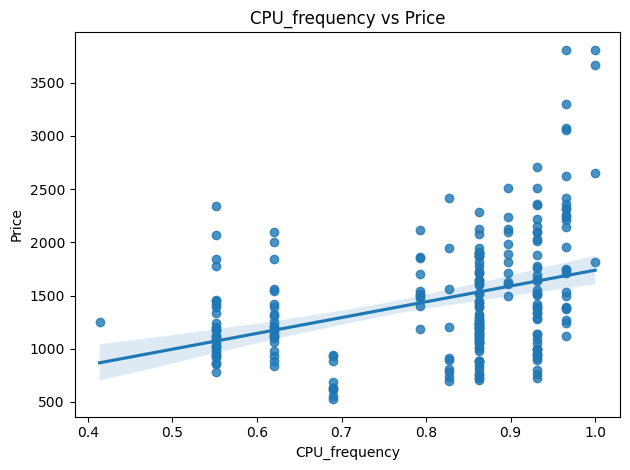

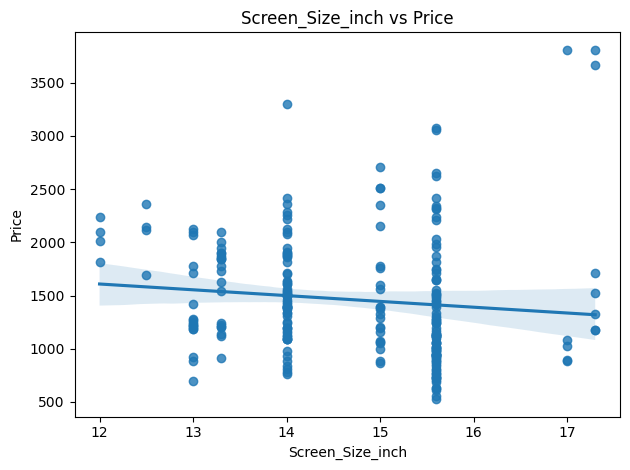

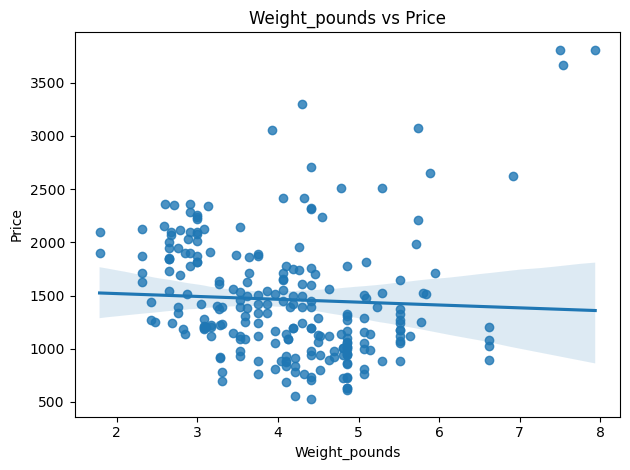

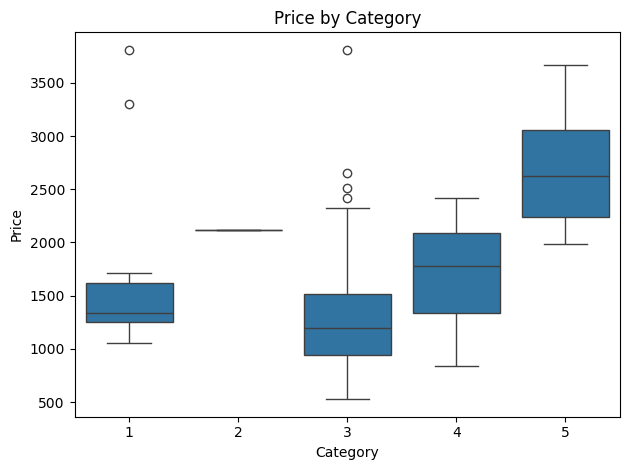

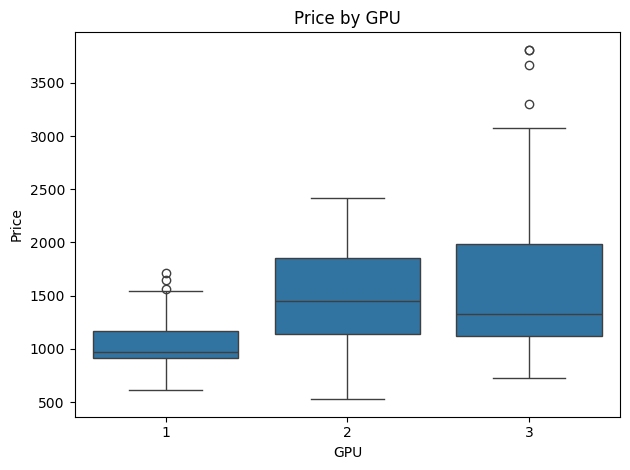

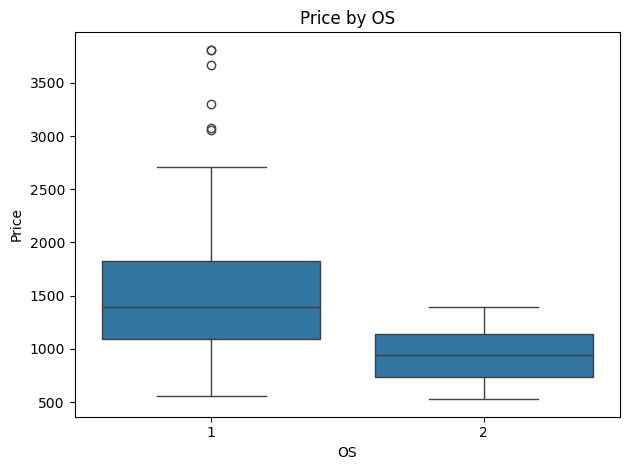

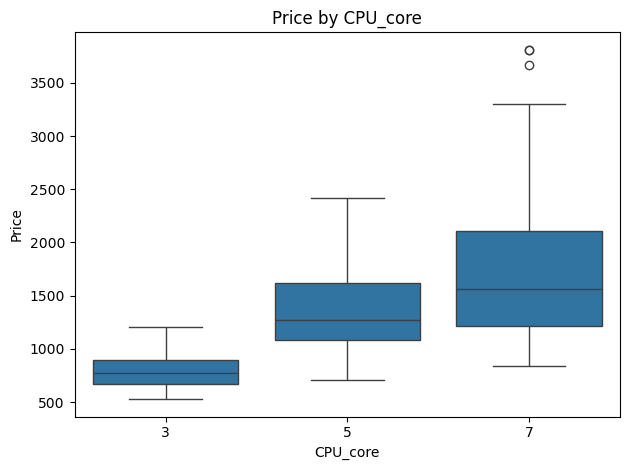

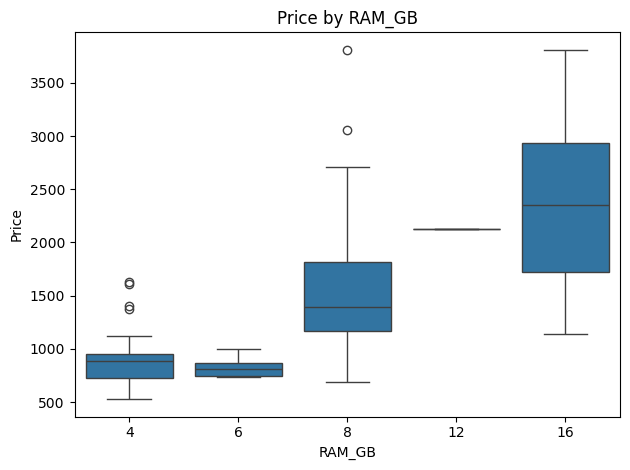

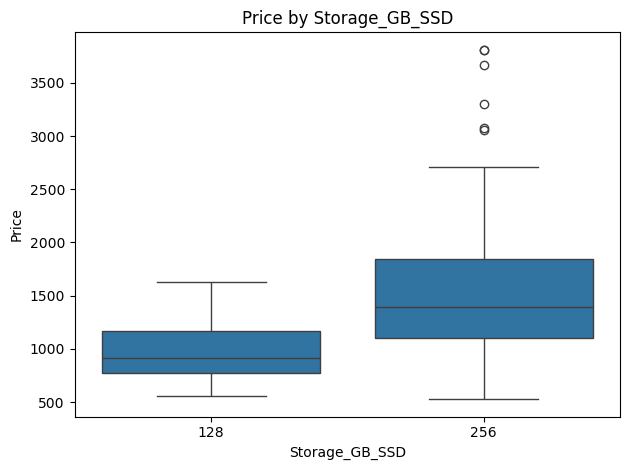

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv', header=0)

for col in ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']: 
    plt.figure() 
    sns.regplot(x=col, y='Price', data=df) 
    plt.title(f'{col} vs Price') 
    plt.tight_layout()

for col in ['Category', 'GPU', 'OS', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']: 
    plt.figure() 
    sns.boxplot(x=col, y='Price', data=df) 
    plt.title(f'Price by {col}') 
    plt.tight_layout()

plt.show()

In [11]:
import pandas as pd 
from scipy.stats import pearsonr

# df = pd.read_csv('data.csv', header=0)

num_cols = df.select_dtypes(include='number').columns.tolist() 
num_cols = [c for c in num_cols if c != 'Price']

rows = [] 
for col in num_cols: 
    s = df[[col, 'Price']].dropna() 
    r = s[col].corr(s['Price']) 
    pr, pval = pearsonr(s[col], s['Price']) 
    rows.append({'attribute': col, 'correlation_value': r, 'pearson_r': pr, 'p_value': pval})

result = pd.DataFrame(rows) 
print(result)

           attribute  correlation_value  pearson_r       p_value
0       Unnamed: 0.1           0.321933   0.321933  3.851058e-07
1         Unnamed: 0           0.321933   0.321933  3.851058e-07
2           Category           0.286243   0.286243  7.225696e-06
3                GPU           0.288298   0.288298  6.166950e-06
4                 OS          -0.221730  -0.221730  5.696643e-04
5           CPU_core           0.459398   0.459398  7.912950e-14
6   Screen_Size_inch          -0.110644  -0.110644  8.853398e-02
7      CPU_frequency           0.366666   0.366666  5.502463e-09
8             RAM_GB           0.549297   0.549297  3.681561e-20
9     Storage_GB_SSD           0.243421   0.243421  1.489892e-04
10     Weight_pounds          -0.050312  -0.050312  4.397694e-01
11    Screen-Full_HD          -0.021075  -0.021075  7.463568e-01
12  Screen-IPS_panel           0.021075   0.021075  7.463568e-01


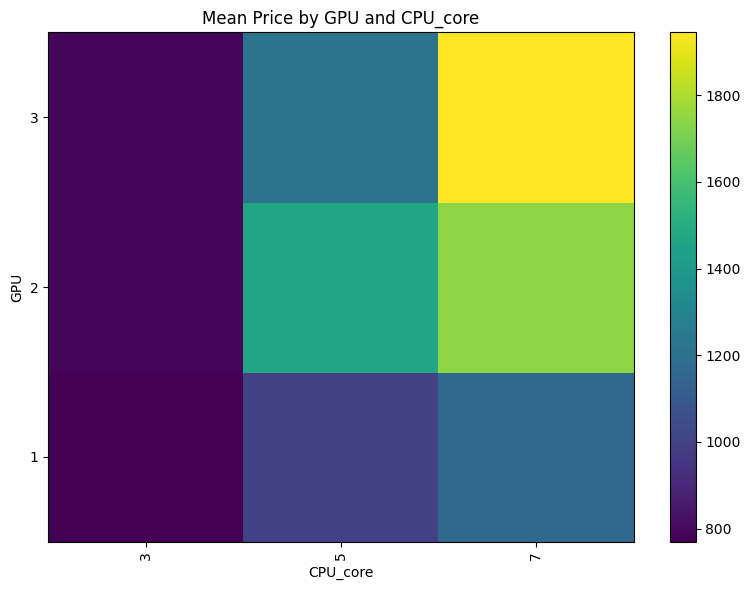

In [14]:
import numpy as np 
import matplotlib.pyplot as plt

pivot = df.pivot_table(index='GPU', columns='CPU_core', values='Price', aggfunc='mean') 
pivot = pivot.fillna(0)

plt.figure(figsize=(8, 6)) 
pc = plt.pcolor(pivot.values, cmap='viridis') 
plt.colorbar(pc) 
plt.xlabel('CPU_core') 
plt.ylabel('GPU') 
plt.xticks(np.arange(0.5, len(pivot.columns), 1), pivot.columns, rotation=90) 
plt.yticks(np.arange(0.5, len(pivot.index), 1), pivot.index) 
plt.title('Mean Price by GPU and CPU_core') 
plt.tight_layout() 

plt.show()